## kNN on Iris Dataset

The k-Nearest Neighbor (kNN) algorithm from scratch using only NumPy. Training and testing performed on the [Iris dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html).

In [27]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [28]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

Text(0, 0.5, 'PCA dim 2')

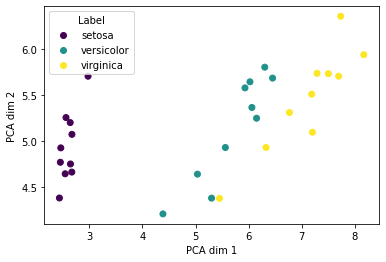

In [29]:
## LOAD DATA AND SPLIT
iris = load_iris()

# PLOTTING A FEW SAMPLES TO GET AN IDEA OF THE DATA
X = iris.data
y = iris.target


Xdf = pd.DataFrame(X, columns = iris.feature_names)
ydf = pd.DataFrame({'label':[iris.target_names[index] for index in y], 'label_index':y})
fulldf = pd.concat([Xdf, ydf], axis=1)

plotdf = fulldf.groupby('label').head(10).copy()

## FIT PCA TO SHRINK FEATURE DIMENSION TO 2 FOR VISUALIZATION
pca = PCA(n_components=2)
X_scaled = StandardScaler().fit_transform(X)
pca.fit(X_scaled) 

## PERFORM PCA ONLY ON NUMERICAL COLUMNS AND IGNORE CATEGORICAL ONES
plotdf_transformed = pca.transform(plotdf.loc[:,:'petal width (cm)'])
plotdf[['pca_1', 'pca_2']] = plotdf_transformed

scatter = plt.scatter(plotdf.pca_1, plotdf.pca_2, c=plotdf.label_index)
handles, _ = scatter.legend_elements()
plt.legend(handles, iris.target_names, title = 'Label')
plt.xlabel('PCA dim 1')
plt.ylabel('PCA dim 2')

In [30]:
## SPLITTING THE DATA
X_train, X_test, y_train, y_test = train_test_split(np.array(fulldf.iloc[:, :4]), np.array(fulldf.label_index), test_size = 0.2)

In [31]:
class KNNClassifier:    
    """K-Nearest Neighbors classifier using only NumPy."""
    
    def __init__(self, k):
        """Initialize KNN classifier, providing k and the training data."""
        self.k = k
    
    def fit(self, X_train, y_train):
        """Fit the model using the training data."""
        scaler = StandardScaler()
        self.X_train = scaler.fit_transform(X_train)
        self.scaler = scaler
        self.Y_train = y_train
        pass
    
    def predict(self, X):
        """Make predictions for an input dataset using majority voting.
        """
        preds_out = []
        X_scaled = self.scaler.transform(X.copy())
        for sample in X_scaled:
            distances = (self.X_train - sample) ** 2
            distances = distances.sum(axis=1) ** 0.5
            k_smallest_indices = np.argpartition(distances, self.k)[:self.k]
        
            labels = self.Y_train[k_smallest_indices]
            classes, counts = np.unique(labels, return_counts=True)
            maxcount = counts.max()

            if np.sum(counts == maxcount) > 1:
                maxindices = np.where(counts==maxcount)[0]
                chosen_index = np.random.choice(maxindices, size=1)
                predicted_label = classes[chosen_index][0]
            else:
                predicted_label = classes[np.where(counts==maxcount)[0]][0]
            
            preds_out.append(predicted_label)
        try:
            return np.array(preds_out)
        except:
            return preds_out


In [32]:
## MODEL TESTING PHASE

for candidate_k in [1, 3, 5]:
    model = KNNClassifier(candidate_k)
    scaler = model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = np.mean(predictions == y_test)
    print(f"LETTING K = {candidate_k}, we achieved an accuracy of {accuracy}")
    
    

LETTING K = 1, we achieved an accuracy of 0.9666666666666667
LETTING K = 3, we achieved an accuracy of 0.9333333333333333
LETTING K = 5, we achieved an accuracy of 0.9333333333333333


## kNN on MNIST Dataset

Running the same NumPy-based kNN implementation on the [MNIST dataset](https://www.wikiwand.com/en/articles/MNIST_database). 

In [34]:
from sklearn.datasets import fetch_openml

def load_mnist_subset(n_train=4000, n_test=1000):
    """Load a subset of MNIST dataset for faster computation."""
    # Load MNIST from OpenML
    mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)
    data_size = n_train + n_test
    test_size = n_test / data_size
    sample_indices = np.random.choice(np.arange(len(mnist['data'])), size = data_size, replace=False)
    X_sample = mnist['data'][sample_indices]
    y_sample = mnist['target'][sample_indices]
    X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size = test_size)
    
    return X_train, X_test, y_train, y_test

In [35]:
X_train, X_test, y_train, y_test = load_mnist_subset()

In [36]:
## MODEL TESTING PHASE

for candidate_k in [1, 3, 5]:
    model = KNNClassifier(candidate_k)
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = np.mean(predictions == y_test)
    print(f"LETTING K = {candidate_k}, we achieved an accuracy of {accuracy}")

LETTING K = 1, we achieved an accuracy of 0.888
LETTING K = 3, we achieved an accuracy of 0.893
LETTING K = 5, we achieved an accuracy of 0.888


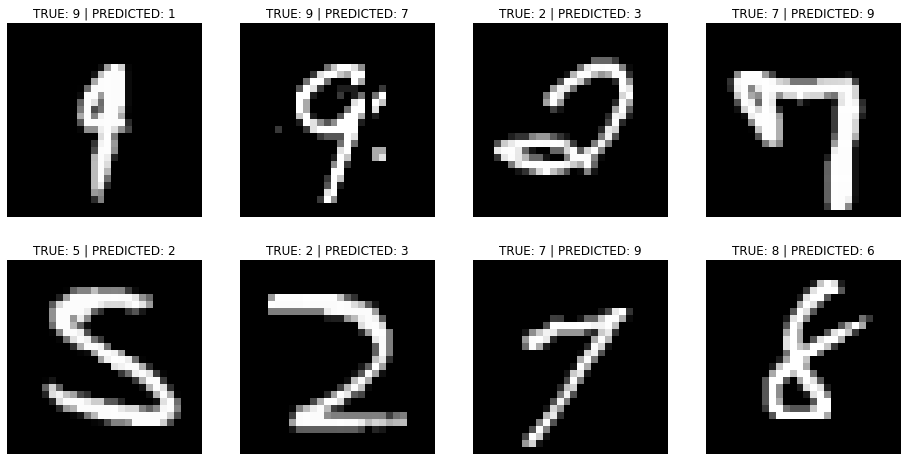

In [38]:
import matplotlib.pyplot as plt

##VISUALIZING WHICH TYPES OF IMAGES WERE MISCLASSIFIED
misclassified = np.where(predictions != y_test)[0]
x_misclassified  = np.random.choice(misclassified, size = 8, replace=False)
x_mis_pics = X_test[x_misclassified]
x_mis_preds = predictions[x_misclassified]
x_mis_true_ys = y_test[x_misclassified]


fig, axes = plt.subplots(2, 4,figsize=(16,8))

for i, ax in enumerate(axes.flat):
    ax.imshow(x_mis_pics[i].reshape(28,28), cmap='gray')
    ax.set_title(f'TRUE: {x_mis_true_ys[i]} | PREDICTED: {x_mis_preds[i]}')
    ax.axis('off')